# 02a — EDA: Thời vụ & biến động theo thời gian

Phần 1/4 của EDA (tách từ `02_eda.ipynb` gốc — xem `docs/analysis/EDA_FINDINGS.md` để đọc phân tích đầy đủ từng chart, file này chỉ giữ code + kết luận ngắn).

Phạm vi: xu hướng theo ngày/tháng/mùa vụ/Tết + doanh thu theo category/vùng/kênh qua các năm.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # notebook vẫn hiện inline qua %matplotlib inline bên dưới
import matplotlib.pyplot as plt
from lunardate import LunarDate

from datathon import config
from datathon.ingestion import load_raw

%matplotlib inline

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55+"]

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

print("DATA_RAW:", config.DATA_RAW)


DATA_RAW: /Users/lhoanghai_/Documents/Study/Dự án datathon2026/data/raw


In [2]:
import os
import trino

_trino_conn = trino.dbapi.connect(
    host=os.environ.get("TRINO_HOST", "localhost"),
    port=int(os.environ.get("TRINO_PORT", "8080")),
    user="notebook_02_eda",
    catalog="iceberg",
    schema="staging",
)
sales = pd.read_sql(
    "SELECT date AS \"Date\", revenue AS \"Revenue\", cogs AS \"COGS\" "
    "FROM mart_revenue_daily ORDER BY date",
    _trino_conn,
)
sales["Date"] = pd.to_datetime(sales["Date"])
assert len(sales) == 3833, f"mart_revenue_daily phải 3833 dòng, đang {len(sales)}"
orders = load_raw("orders")
items = load_raw("order_items")
products = load_raw("products")
customers = load_raw("customers")
geography = load_raw("geography")
promotions = load_raw("promotions")
returns = load_raw("returns")
payments = load_raw("payments")

for name, df in [("sales", sales), ("orders", orders), ("order_items", items),
                  ("products", products), ("customers", customers),
                  ("geography", geography), ("promotions", promotions),
                  ("returns", returns), ("payments", payments)]:
    print(f"{name:14s} {df.shape}")


sales          (3833, 3)
orders         (646945, 8)
order_items    (714669, 7)
products       (2412, 8)
customers      (121930, 7)
geography      (39948, 4)
promotions     (50, 10)
returns        (39939, 7)
payments       (646945, 4)


In [3]:
# customers đã có sẵn cột 'zip' (khác bản gốc chỉ usecols acquisition_channel/signup_date) ->
# drop trước khi merge để tránh đụng 'zip' đã có từ orders (tránh bị pandas tự suffix zip_x/zip_y).
customers_nozip = customers.drop(columns=["zip"])

li = (items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(customers_nozip, on="customer_id", how="left")
      .merge(geography, on="zip", how="left")
      .merge(promotions, on="promo_id", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["line_cogs"] = li["quantity"] * li["cogs"]
li["year"] = li["order_date"].dt.year
li["month"] = li["order_date"].dt.month
li = li[li["year"].between(2013, 2022)].copy()

chk = li.groupby(li["order_date"])["line_revenue"].sum()
sales_idx = sales.set_index("Date")["Revenue"]
diff = ((chk.reindex(sales_idx.index) - sales_idx).abs() / sales_idx).mean() * 100
print(f"Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: {diff:.3f}% (kỳ vọng ~0%)")
print(f"{len(li):,} dòng sau join, {li['customer_id'].nunique():,} khách")


Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: 0.000% (kỳ vọng ~0%)
677,662 dòng sau join, 89,063 khách


## Xu hướng & mùa vụ chung (`sales`)

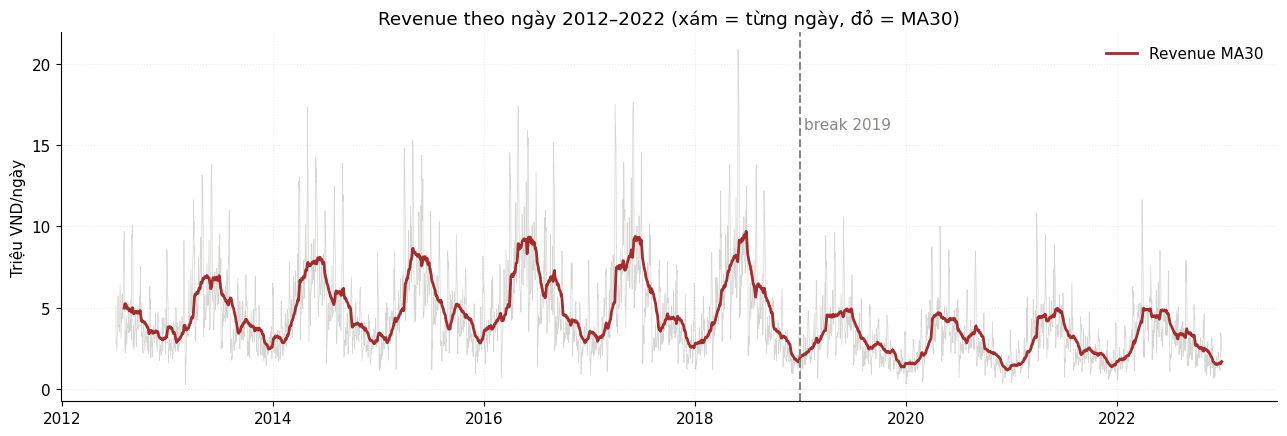

In [4]:
sales = sales.rename(columns={"Date": "Date"}).sort_values("Date").reset_index(drop=True)
sales["margin_pct"] = (sales["Revenue"] - sales["COGS"]) / sales["Revenue"] * 100
sales["MA30"] = sales["Revenue"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(sales["Date"], sales["Revenue"] / 1e6, color=C_GRAY, alpha=0.35, lw=0.5)
ax.plot(sales["Date"], sales["MA30"] / 1e6, color=C_REV, lw=2, label="Revenue MA30")
ax.axvline(pd.Timestamp("2019-01-01"), color=C_GRAY, ls="--", lw=1.5)
ax.annotate("break 2019", xy=(pd.Timestamp("2019-01-15"), 16), color=C_GRAY)
ax.set_ylabel("Triệu VND/ngày")
ax.set_title("Revenue theo ngày 2012–2022 (xám = từng ngày, đỏ = MA30)")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()


Đỉnh thật là 2016 (2.105 tỷ), không phải 2018. Suy giảm bắt đầu Q4/2018 (YoY tháng 10 -23.6%, tháng 11 -32.7%), không phải đột ngột 01/01/2019. 2022 mới hồi phục 63% mức đỉnh.

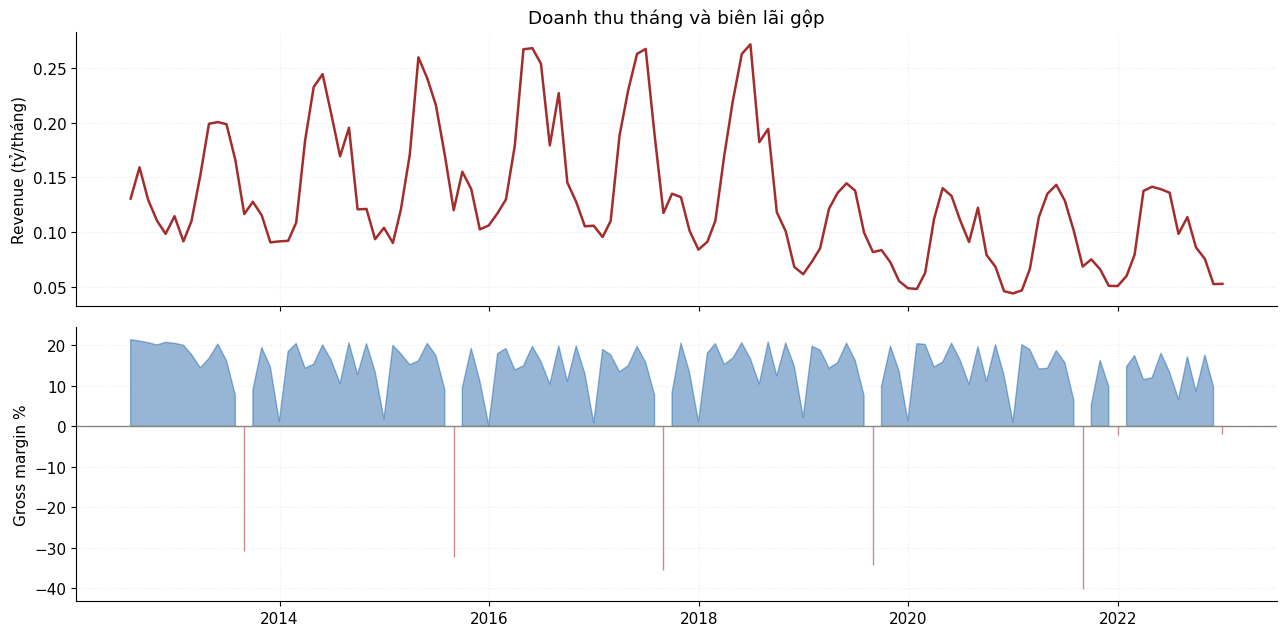

In [5]:
monthly = sales.set_index("Date").resample("ME")[["Revenue", "COGS"]].sum()
monthly["margin_pct"] = (monthly["Revenue"] - monthly["COGS"]) / monthly["Revenue"] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
ax1.plot(monthly.index, monthly["Revenue"] / 1e9, color=C_REV, lw=1.8)
ax1.set_ylabel("Revenue (tỷ/tháng)")
ax1.set_title("Doanh thu tháng và biên lãi gộp")
ax2.fill_between(monthly.index, monthly["margin_pct"], 0,
                 where=monthly["margin_pct"] >= 0, color=C_COGS, alpha=0.45)
ax2.fill_between(monthly.index, monthly["margin_pct"], 0,
                 where=monthly["margin_pct"] < 0, color=C_REV, alpha=0.55)
ax2.axhline(0, color=C_GRAY, lw=1)
ax2.set_ylabel("Gross margin %")
fig.tight_layout(); plt.show()


7/126 tháng margin âm, 5/7 rơi đúng tháng 8 (chu kỳ 2 năm, xem chart category/promo phần Nguyên nhân). Đáy -40.09% (08/2021), đỉnh +21.39% (07/2012, mẫu nhỏ tháng mở shop).

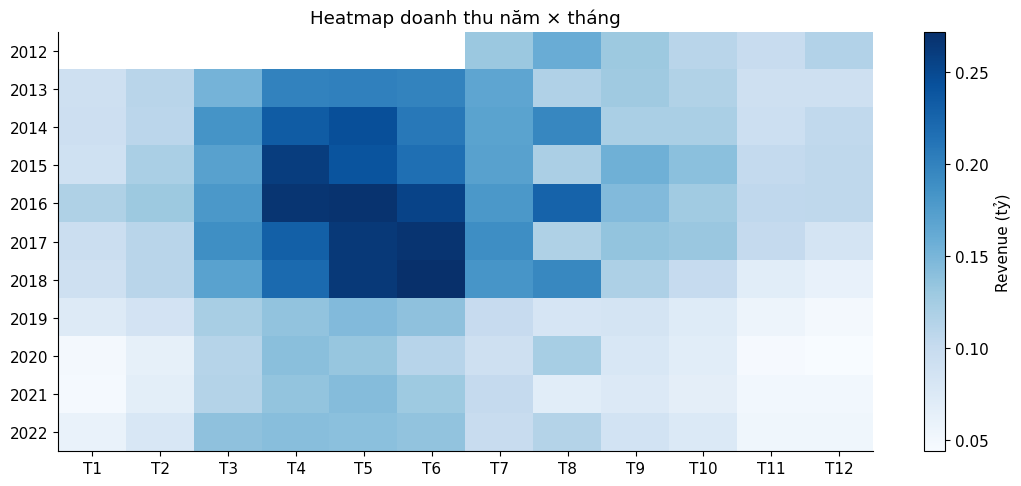

In [6]:
hm = sales.pivot_table(index=sales["Date"].dt.year, columns=sales["Date"].dt.month,
                       values="Revenue", aggfunc="sum") / 1e9
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(hm.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(12), [f"T{m}" for m in range(1, 13)])
ax.set_yticks(range(len(hm.index)), hm.index)
ax.grid(False)
fig.colorbar(im, label="Revenue (tỷ)")
ax.set_title("Heatmap doanh thu năm × tháng")
fig.tight_layout(); plt.show()


Ô nóng nhất tháng 6/2018 (271.7 triệu VND), lạnh nhất tháng 12/2020 (43.7 triệu — đáy kép COVID + mùa thấp điểm).

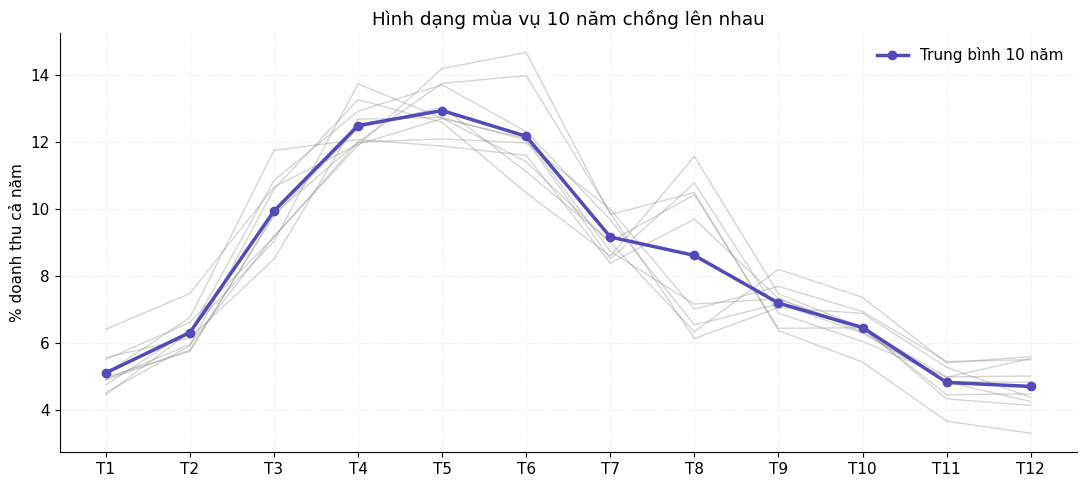

Tỷ trọng tháng (TB % ± std qua 10 năm):
  T1 :  5.11% +/- 0.58
  T2 :  6.32% +/- 0.53
  T3 :  9.95% +/- 1.01
  T4 : 12.50% +/- 0.64
  T5 : 12.95% +/- 0.74
  T6 : 12.18% +/- 1.27
  T7 :  9.17% +/- 0.62
  T8 :  8.62% +/- 2.15
  T9 :  7.20% +/- 0.55
  T10:  6.47% +/- 0.53
  T11:  4.83% +/- 0.55
  T12:  4.71% +/- 0.74


In [7]:
yr = sales[sales["Date"].dt.year.between(2013, 2022)].copy()
yr["year"], yr["month"] = yr["Date"].dt.year, yr["Date"].dt.month
share = (yr.groupby(["year", "month"])["Revenue"].sum()
         / yr.groupby("year")["Revenue"].sum()).unstack() * 100

fig, ax = plt.subplots(figsize=(11, 5))
for y in share.index:
    ax.plot(share.columns, share.loc[y], color=C_GRAY, alpha=0.35, lw=1)
ax.plot(share.columns, share.mean(), color=C_ACCENT, lw=2.5, marker="o", label="Trung bình 10 năm")
ax.set_xticks(range(1, 13), [f"T{m}" for m in range(1, 13)])
ax.set_ylabel("% doanh thu cả năm")
ax.set_title("Hình dạng mùa vụ 10 năm chồng lên nhau")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

print("Tỷ trọng tháng (TB % ± std qua 10 năm):")
for m in range(1, 13):
    print(f"  T{m:<2}: {share[m].mean():5.2f}% +/- {share[m].std():.2f}")


Cao điểm Tháng 4-6 (12-13% doanh thu năm/tháng), thấp điểm Tháng 11-12 (4.7-4.8%) — ngược mùa mua sắm cuối năm kiểu phương Tây. Tháng 8 biến động bất thường (std=2.15, gấp 3-4 lần tháng khác).

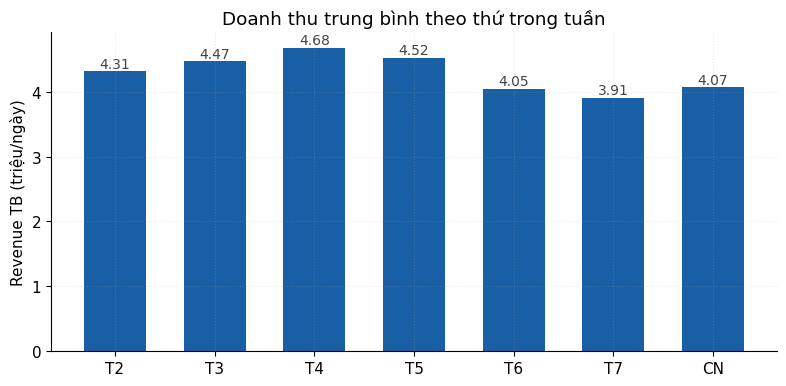

Chênh cao nhất vs thấp nhất trong tuần: 19.8%


In [8]:
dow = sales.groupby(sales["Date"].dt.dayofweek)["Revenue"].mean() / 1e6
labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, dow.values, color=C_COGS, width=0.62)
for i, v in enumerate(dow.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10, color="#444441")
ax.set_ylabel("Revenue TB (triệu/ngày)")
ax.set_title("Doanh thu trung bình theo thứ trong tuần")
fig.tight_layout(); plt.show()

print(f"Chênh cao nhất vs thấp nhất trong tuần: {(dow.max()/dow.min()-1)*100:.1f}%")


Thứ 4 cao nhất (4.68 triệu/ngày), Thứ 7 thấp nhất (3.91 triệu) — chênh 19.8%, có ý nghĩa thống kê (t-test p=0.000003). Nguyên nhân chưa xác định được trong phạm vi dữ liệu này.

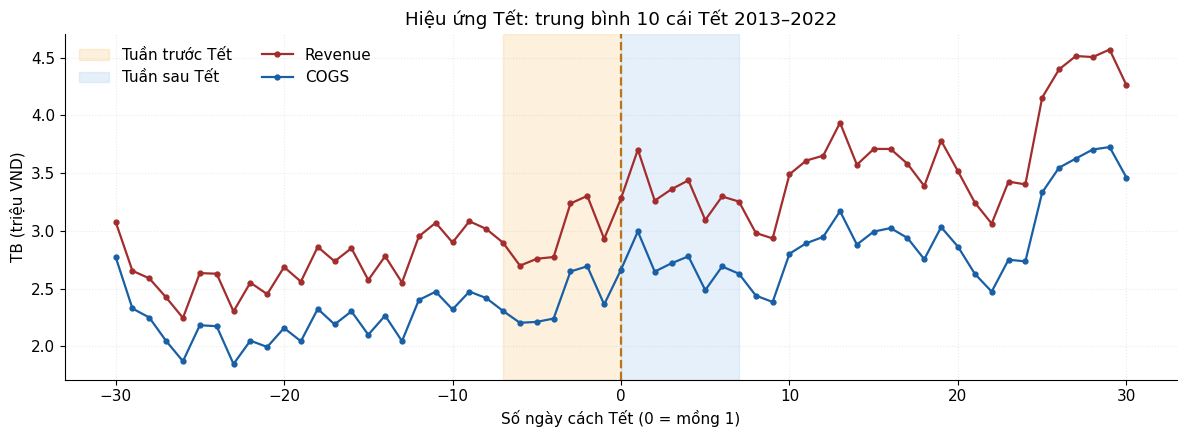

Corr(Revenue, COGS) theo ngày: 0.9760
Tỷ lệ COGS/Revenue: TB 0.875, std 0.127
Top 5 ngày doanh thu cao nhất:
  2018-05-30    20.9 triệu
  2018-05-31    19.3 triệu
  2018-06-01    19.2 triệu
  2017-06-01    17.6 triệu
  2018-06-02    17.5 triệu


In [9]:
tet_dates = [pd.Timestamp(LunarDate(y, 1, 1).to_solar_date()) for y in range(2013, 2023)]
frames = []
for t in tet_dates:
    w = sales[(sales["Date"] >= t - pd.Timedelta(days=30)) &
              (sales["Date"] <= t + pd.Timedelta(days=30))].copy()
    w["offset"] = (w["Date"] - t).dt.days
    frames.append(w)
avg = pd.concat(frames).groupby("offset")[["Revenue", "COGS"]].mean() / 1e6

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axvspan(-7, 0, color="#FAC775", alpha=0.25, label="Tuần trước Tết")
ax.axvspan(0, 7, color="#B5D4F4", alpha=0.35, label="Tuần sau Tết")
ax.axvline(0, color="#BA7517", ls="--", lw=1.6)
ax.plot(avg.index, avg["Revenue"], "o-", color=C_REV, ms=3.5, lw=1.6, label="Revenue")
ax.plot(avg.index, avg["COGS"], "o-", color=C_COGS, ms=3.5, lw=1.6, label="COGS")
ax.set_xlabel("Số ngày cách Tết (0 = mồng 1)")
ax.set_ylabel("TB (triệu VND)")
ax.set_title("Hiệu ứng Tết: trung bình 10 cái Tết 2013–2022")
ax.legend(frameon=False, ncol=2)
fig.tight_layout(); plt.show()

print(f"Corr(Revenue, COGS) theo ngày: {sales['Revenue'].corr(sales['COGS']):.4f}")
print(f"Tỷ lệ COGS/Revenue: TB {(sales['COGS']/sales['Revenue']).mean():.3f}, "
      f"std {(sales['COGS']/sales['Revenue']).std():.3f}")
top5 = sales.nlargest(5, "Revenue")[["Date", "Revenue"]]
print("Top 5 ngày doanh thu cao nhất:")
for _, r in top5.iterrows():
    print(f"  {r['Date'].date()}  {r['Revenue']/1e6:6.1f} triệu")


Top 5 ngày doanh thu cao nhất TOÀN KỲ đều rơi cuối T5-đầu T6, KHÔNG phải ngày Tết. Hiệu ứng Tết phần lớn là nhiễu trộn với mùa vụ (so cùng tháng: 5 năm dương/5 năm âm, không nhất quán).

## Doanh thu theo category / vùng / kênh qua các năm (`li`)

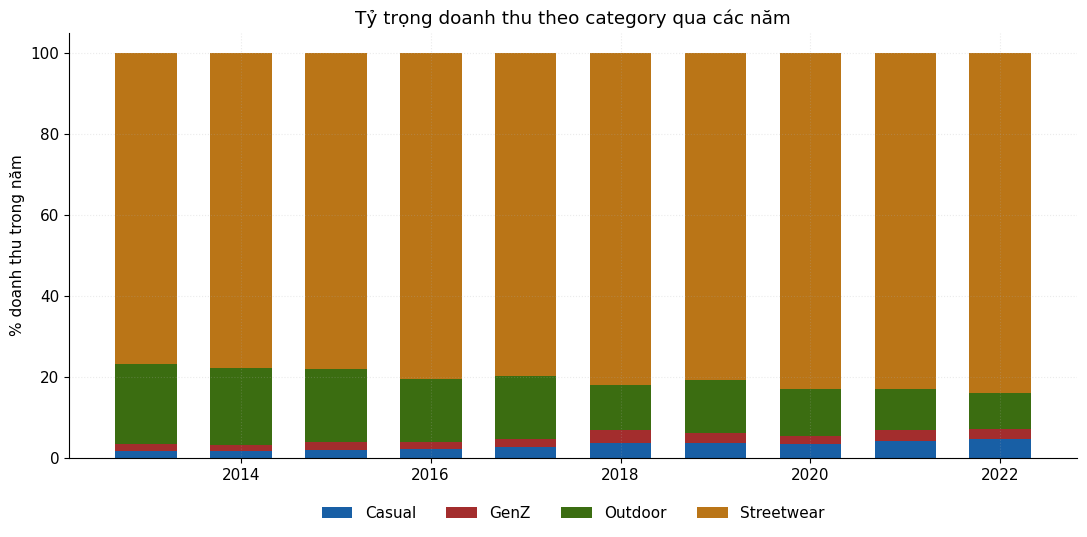

2013: {'Casual': 1.8, 'GenZ': 1.6, 'Outdoor': 19.8, 'Streetwear': 76.8}
2022: {'Casual': 4.6, 'GenZ': 2.5, 'Outdoor': 9.0, 'Streetwear': 83.8}


In [10]:
cat_yr = li.groupby(["year", "category"])["line_revenue"].sum().unstack()
cat_share = cat_yr.div(cat_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(cat_share))
for i, cat in enumerate(cat_share.columns):
    ax.bar(cat_share.index, cat_share[cat], bottom=bottom, label=cat,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += cat_share[cat].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo category qua các năm")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); plt.show()

print(f"2013: {cat_share.loc[2013].round(1).to_dict()}")
print(f"2022: {cat_share.loc[2022].round(1).to_dict()}")


Streetwear tăng thị phần 76.8%→83.8% (2013→2022) nhưng doanh thu TUYỆT ĐỐI giảm 23% — thắng chỉ vì Outdoor giảm nhanh hơn (-67.8%).

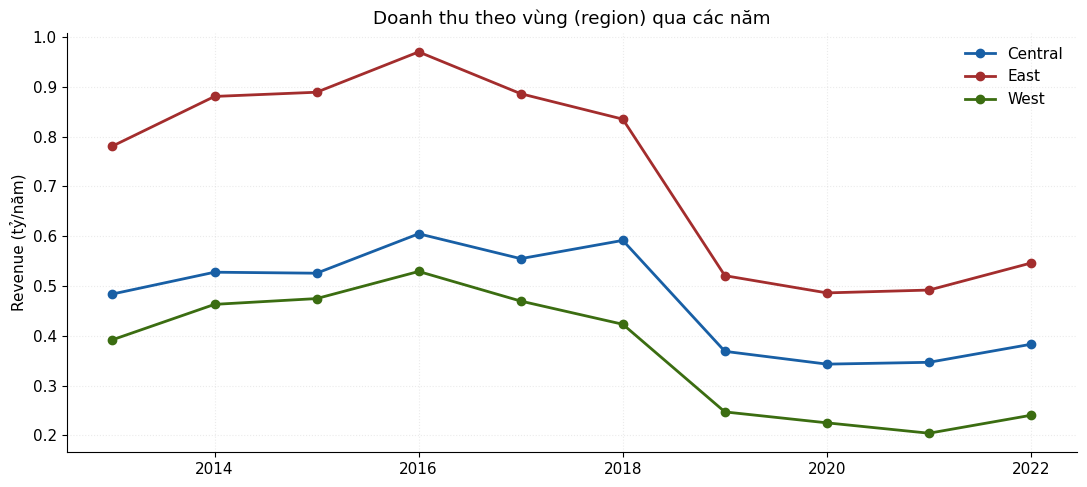

2022 (tỷ VND): {'Central': 0.4, 'East': 0.5, 'West': 0.2}


In [11]:
reg_yr = li.groupby(["year", "region"])["line_revenue"].sum().unstack() / 1e9
fig, ax = plt.subplots(figsize=(11, 5))
for i, reg in enumerate(reg_yr.columns):
    ax.plot(reg_yr.index, reg_yr[reg], "o-", color=PALETTE[i % len(PALETTE)], lw=2, label=reg)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu theo vùng (region) qua các năm")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()
print(f"2022 (tỷ VND): {reg_yr.loc[2022].round(1).to_dict()}")


Cả 3 vùng đều giảm 2013-2022 (Central -21%, East -30%, West -39% dù West margin tốt nhất) — suy giảm toàn hệ thống, không phải dịch chuyển giữa vùng.

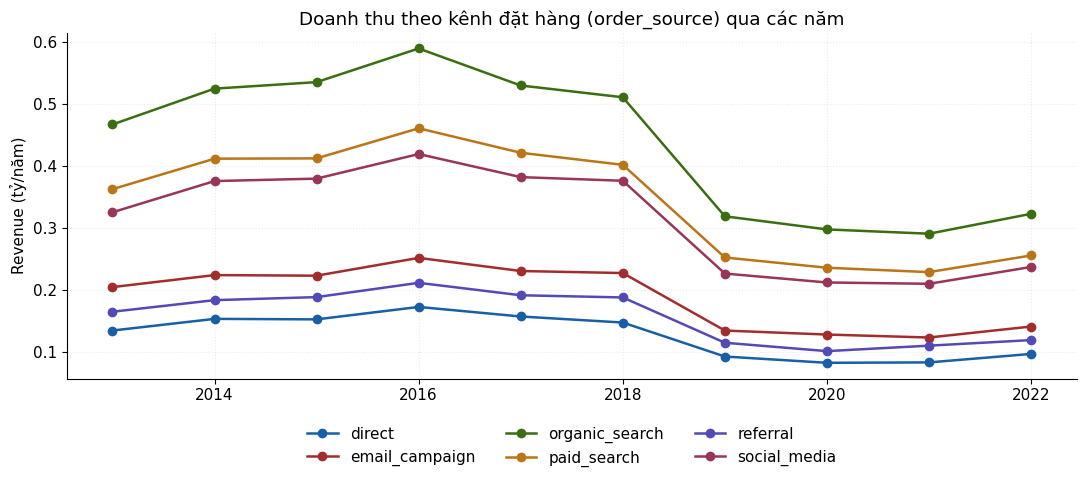

Sụt giảm revenue 2018->2019 theo kênh (%): {'direct': -37.4, 'email_campaign': -41.0, 'organic_search': -37.7, 'paid_search': -37.3, 'referral': -39.1, 'social_media': -39.9}


In [12]:
src_yr = li.groupby(["year", "order_source"])["line_revenue"].sum().unstack() / 1e9
fig, ax = plt.subplots(figsize=(11, 5))
for i, src in enumerate(src_yr.columns):
    ax.plot(src_yr.index, src_yr[src], "o-", color=PALETTE[i % len(PALETTE)], lw=1.8, label=src)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu theo kênh đặt hàng (order_source) qua các năm")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); plt.show()

drop_by_channel = (src_yr.loc[2019] / src_yr.loc[2018] - 1) * 100
print("Sụt giảm revenue 2018->2019 theo kênh (%):", drop_by_channel.round(1).to_dict())


Sụt giảm 2018→2019 xảy ra đều trên MỌI kênh (-37% đến -41%, chênh dưới 4 điểm %) — cú sốc hệ thống, không phải 1 kênh cụ thể hỏng.